In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv')
df.drop(['id', 'Unnamed: 0'], axis=1, inplace=True, errors='ignore')
print(df.head())

         date     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  20141013T000000  221900.0       3.0       1.00         1180      5650     1.0   
1  20141209T000000  538000.0       3.0       2.25         2570      7242     2.0   
2  20150225T000000  180000.0       2.0       1.00          770     10000     1.0   
3  20141209T000000  604000.0       4.0       3.00         1960      5000     1.0   
4  20150218T000000  510000.0       3.0       2.00         1680      8080     1.0   

   waterfront  view  condition  grade  sqft_above  sqft_basement  yr_built  \
0         0.0     0          3      7        1180              0      1955   
1         0.0     0          3      7        2170            400      1951   
2         0.0     0          3      6         770              0      1933   
3         0.0     0          5      7        1050            910      1965   
4         0.0     0          3      8        1680              0      1987   

   yr_renovated  zipcode      l

In [ ]:
print(df.dtypes)

missing = df.isnull().sum()
print('\nMissing values:')
print(missing[missing > 0])

df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)
df['bathrooms'].fillna(df['bathrooms'].mean(), inplace=True)

print()
print(df['price'].describe())

date             object
price           float64
bedrooms        float64
bathrooms       float64
sqft_living       int64
sqft_lot          int64
floors          float64
waterfront      float64
view              int64
condition         int64
grade             int64
sqft_above        int64
sqft_basement     int64
yr_built          int64
yr_renovated    float64
zipcode           int64
lat             float64
long            float64
sqft_living15   float64
sqft_lot15      float64
dtype: object

Missing values:
bedrooms     13
bathrooms    13
dtype: int64

count    21613.000000
mean    540088.141765
std     367127.196482
min      75000.000000
25%     321950.000000
50%     450000.000000
75%     645000.000000
max    7700000.000000
Name: price, dtype: float64


In [ ]:
print('Unique floor values:')
print(df['floors'].value_counts())

print('\nCorrelation with price:')
print(df.select_dtypes(include='number').corr()['price'].drop('price').sort_values(ascending=False))

Unique floor values:
1.0    10673
2.0     8241
1.5     1910
3.0      613
2.5      161
3.5       15
Name: floors, dtype: int64

Correlation with price:
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585241
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


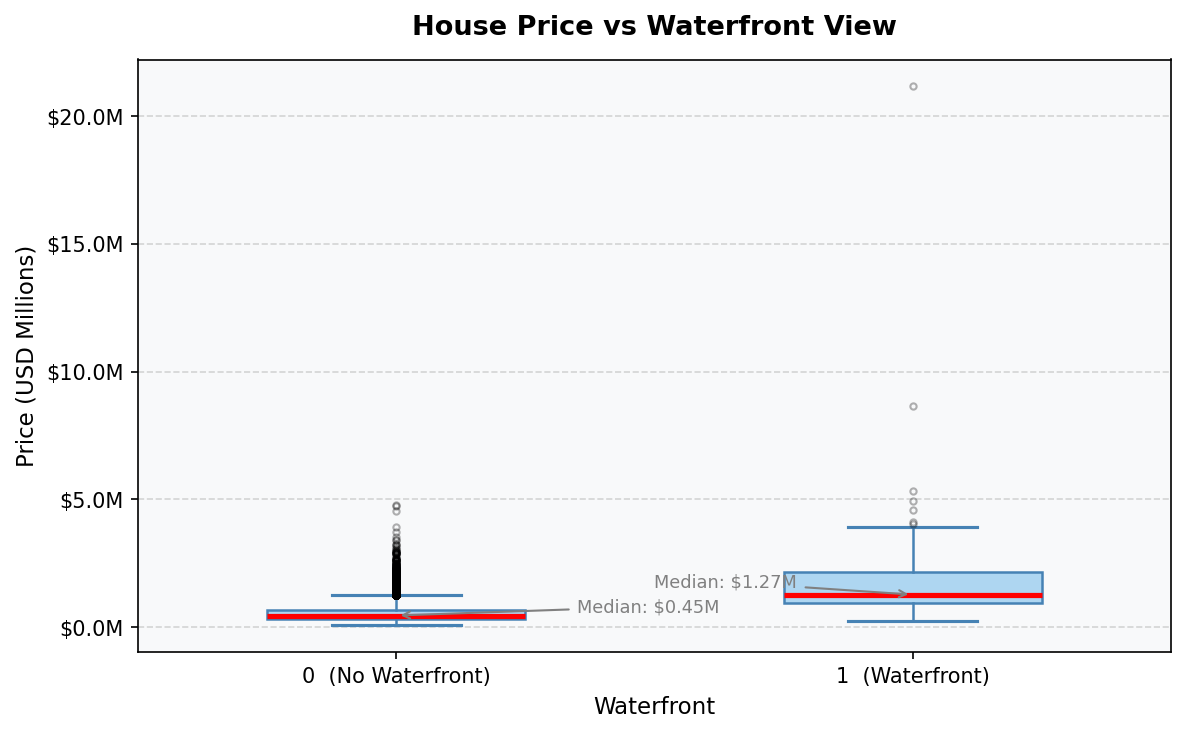

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='price', by='waterfront', ax=ax)
ax.set_title('Price vs Waterfront')
ax.set_xlabel('Waterfront (0 = No, 1 = Yes)')
ax.set_ylabel('Price (USD)')
plt.suptitle('')
plt.tight_layout()
plt.show()

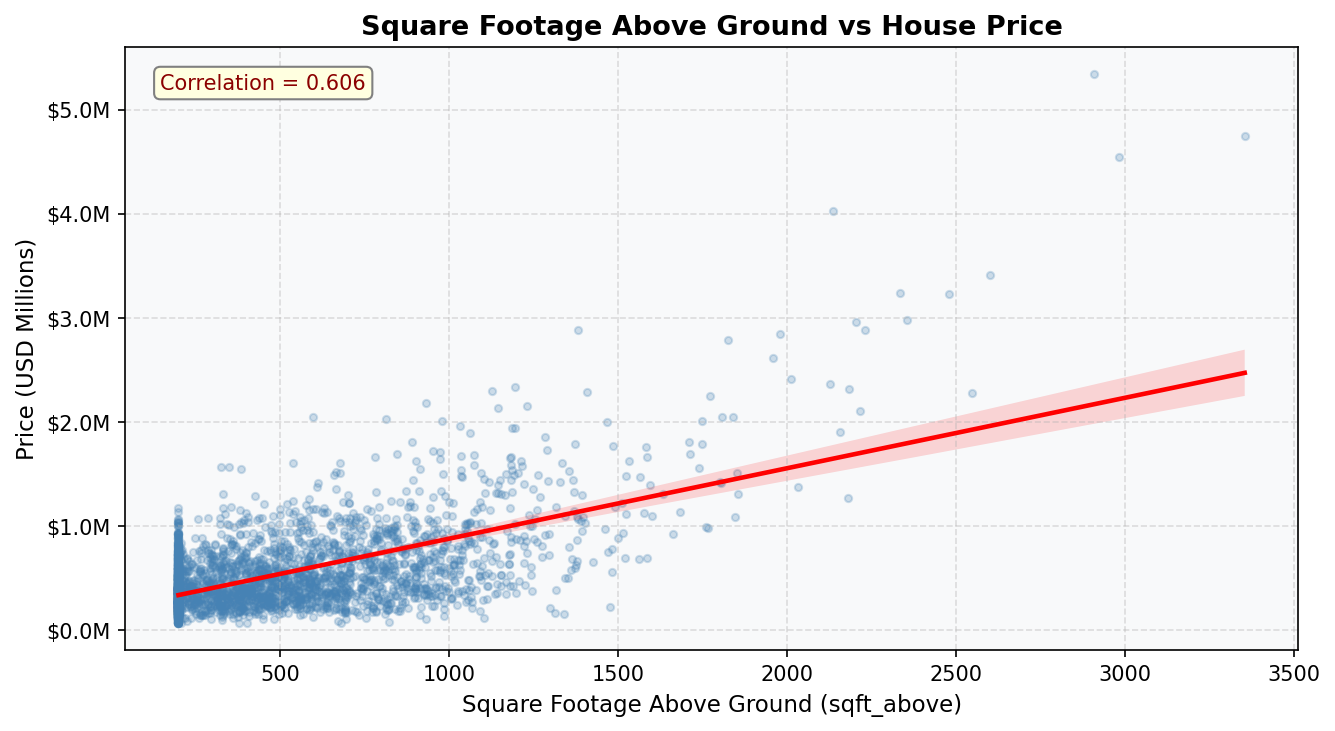

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='sqft_above', y='price', data=df, ax=ax,
            scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
            line_kws={'color': 'red'})
ax.set_title('sqft_above vs Price')
ax.set_xlabel('Square Footage Above Ground')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

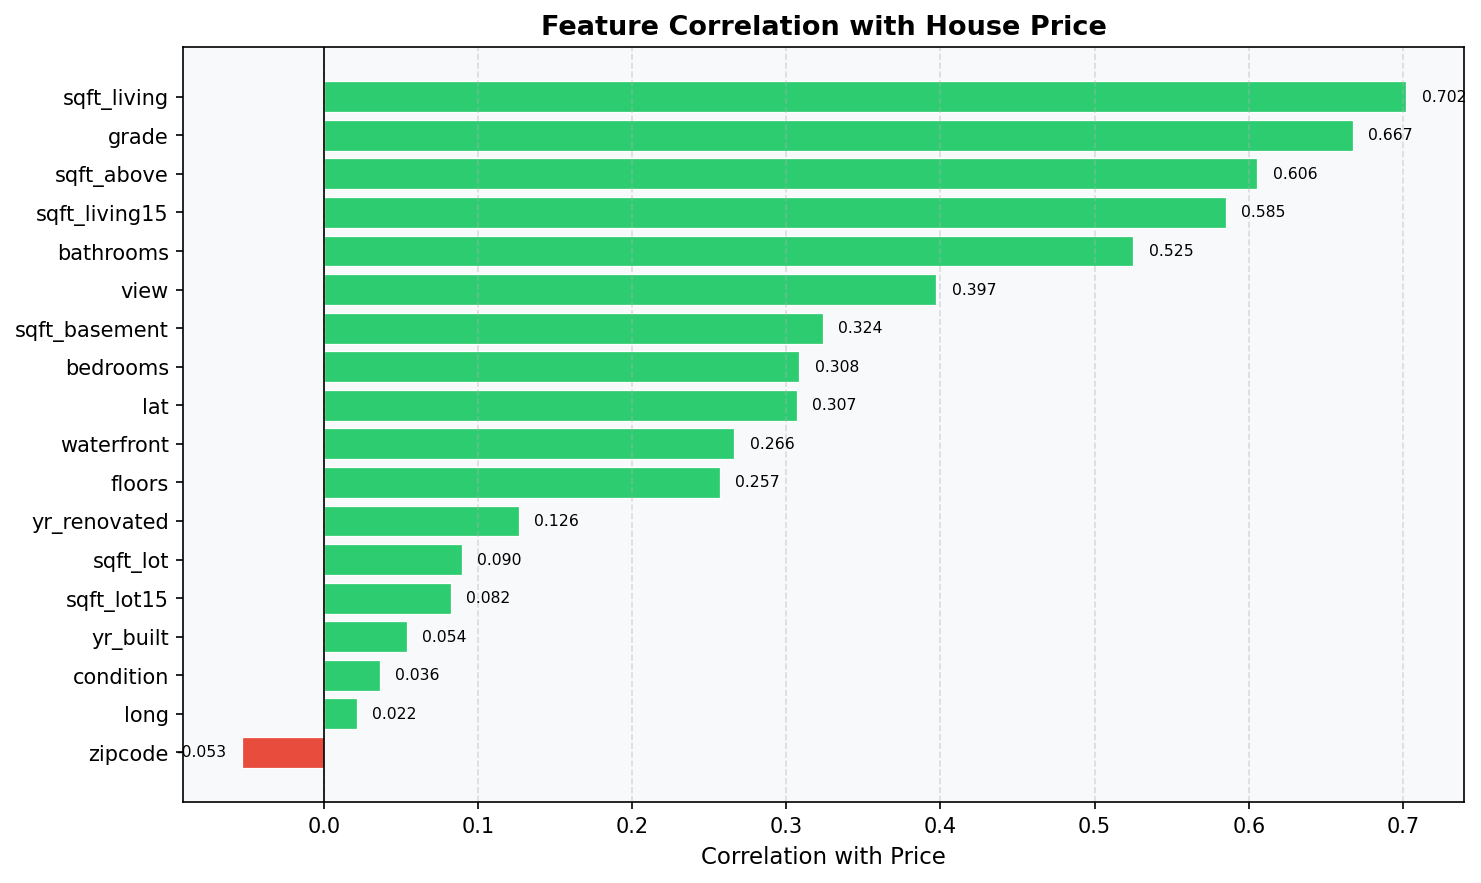

In [ ]:
# Feature correlation with price — bar chart
corr = df.select_dtypes(include='number').corr()['price'].drop('price').sort_values()
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr.values]
fig, ax = plt.subplots(figsize=(10, 6))
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Price')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [ ]:
Y = df['price']
features = ['floors','waterfront','lat','bedrooms','sqft_basement',
            'view','bathrooms','sqft_living15','sqft_above','grade','sqft_living']

lm1 = LinearRegression()
lm1.fit(df[['long']], Y)
print(f"SLR R2 (long):          {lm1.score(df[['long']], Y):.5f}")

lm2 = LinearRegression()
lm2.fit(df[['sqft_living']], Y)
print(f"SLR R2 (sqft_living):   {lm2.score(df[['sqft_living']], Y):.5f}")

lm3 = LinearRegression()
lm3.fit(df[features], Y)
print(f"MLR R2 (11 features):   {lm3.score(df[features], Y):.5f}")

pipe = Pipeline([('scale', StandardScaler()),
                 ('polynomial', PolynomialFeatures(degree=2, include_bias=False)),
                 ('model', LinearRegression())])
pipe.fit(df[features], Y)
print(f"Pipeline Poly R2:       {pipe.score(df[features], Y):.5f}")

SLR R2 (long):          0.00047
SLR R2 (sqft_living):   0.49285
MLR R2 (11 features):   0.65768
Pipeline Poly R2:       0.75018


Ridge R2 (test):             0.64773
Polynomial Ridge R2 (test):  0.70021


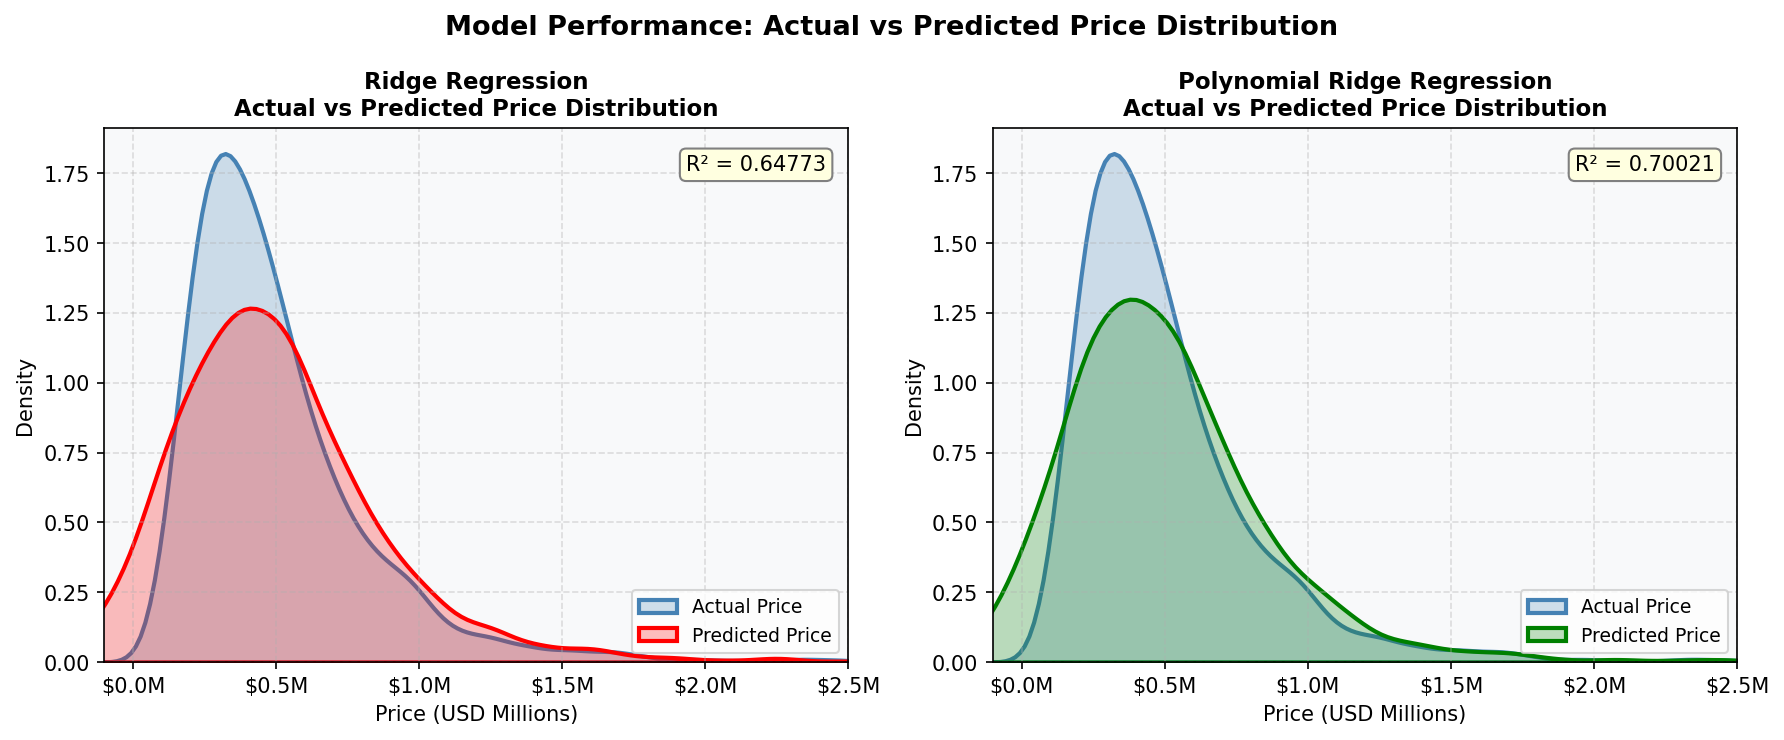

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df[features], Y, test_size=0.2, random_state=1)

ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)
yhat = ridge.predict(x_test)
print(f"Ridge R2 (test):             {r2_score(y_test, yhat):.5f}")

pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr  = pr.transform(x_test)
ridge_poly = Ridge(alpha=0.1)
ridge_poly.fit(x_train_pr, y_train)
yhat_poly = ridge_poly.predict(x_test_pr)
print(f"Polynomial Ridge R2 (test):  {r2_score(y_test, yhat_poly):.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(y_test, color='blue', label='Actual', ax=axes[0])
sns.kdeplot(yhat, color='red', label='Predicted', ax=axes[0])
axes[0].set_title('Ridge: Actual vs Predicted')
axes[0].legend()
sns.kdeplot(y_test, color='blue', label='Actual', ax=axes[1])
sns.kdeplot(yhat_poly, color='green', label='Predicted', ax=axes[1])
axes[1].set_title('Poly Ridge: Actual vs Predicted')
axes[1].legend()
plt.tight_layout()
plt.show()


=== MODEL SUMMARY ===
SLR (long)                  R2 = 0.00047
SLR (sqft_living)           R2 = 0.49285
Multiple Linear Regression  R2 = 0.65768
Pipeline Polynomial (deg 2) R2 = 0.75018
Ridge Regression (test)     R2 = 0.64773
Poly Ridge Regression (test)R2 = 0.70021  <-- Best on unseen data


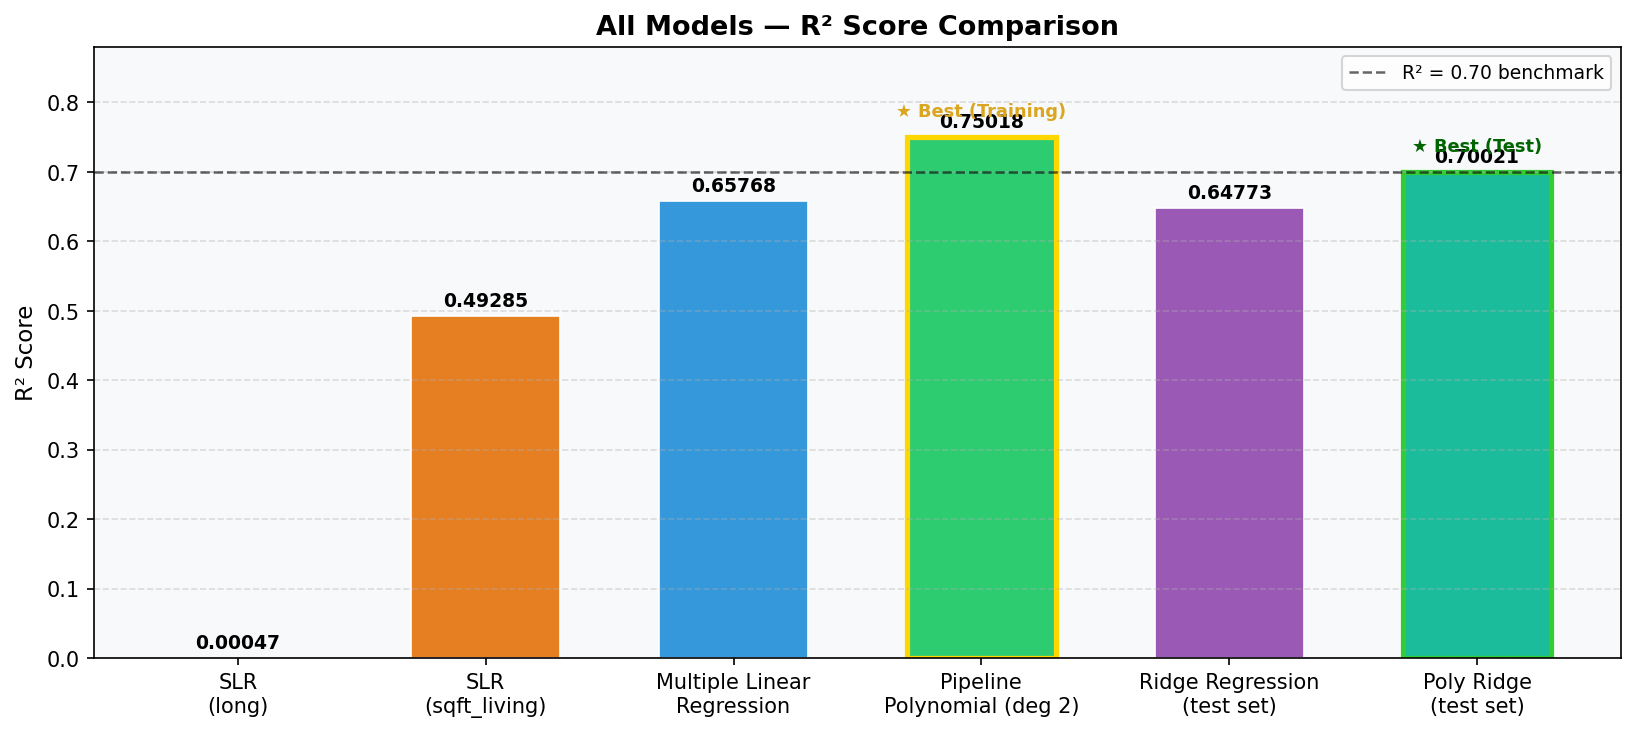

In [ ]:
print('\n=== MODEL SUMMARY ===')
print(f"SLR (long)                  R2 = {lm1.score(df[['long']], Y):.5f}")
print(f"SLR (sqft_living)           R2 = {lm2.score(df[['sqft_living']], Y):.5f}")
print(f"Multiple Linear Regression  R2 = {lm3.score(df[features], Y):.5f}")
print(f"Pipeline Polynomial (deg 2) R2 = {pipe.score(df[features], Y):.5f}")
print(f"Ridge Regression (test)     R2 = {r2_score(y_test, yhat):.5f}")
print(f"Poly Ridge Regression (test)R2 = {r2_score(y_test, yhat_poly):.5f}  <-- Best on unseen data")

# Model comparison bar chart
model_names = ['SLR (long)', 'SLR (sqft_living)', 'MLR', 'Pipeline Poly', 'Ridge (test)', 'Poly Ridge (test)']
r2_vals = [0.00047, 0.49285, 0.65768, 0.75018, 0.64773, 0.70021]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(model_names, r2_vals, color=['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#1abc9c'])
ax.set_ylabel('R2 Score')
ax.set_title('All Models — R2 Score Comparison')
plt.tight_layout()
plt.show()